In [ ]:
%load_ext autoreload
%autoreload 2

from datetime import datetime
import json
import numpy as np
from pathlib import Path
import os
from typing import Any, List, Optional, Tuple
import itertools

from smt.sampling_methods import LHS
from smt.surrogate_models import MixIntKernelType

from comcatalyst.vars.var_metadata import VarMetadata
from comcatalyst.vars.vars_metadata import VarsMetadata
from comcatalyst.xprs.fn_objectives import calc_gp_objective_01, calc_gp_objective_02, calc_gp_objective_03
from comcatalyst.xprs.xpr_moda import XPRModA, XPRModAHyperparams, XPRModAResultRunXpr
from comcatalyst.xprs.visualizations import (
    plot_ground_truth,
    plot_3d_ground_truth
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# **Functions.**

In [ ]:
def log_error(msg: str, save_path: str) -> None:
    if save_path is None:
        return
    timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    log_line  = f"[{timestamp}] {msg}\n"
    with open(save_path, "a") as f:
        f.write(log_line)
    print(f"  [LOG] {log_line.strip()}")

def benchmark(
    fn_gp_objective: callable,
    vars_metadata: Any,
    z: Any,
    x_true_max: np.ndarray,
    y_true_max: float,
    seeds: List[int],
    fixed_hyperparams_dict: dict,
    varying_hyperparams_dict: List[Tuple[str, List[Any]]],
    save_path_results: str,
    save_path_logs: str,
    seed_ydoe_offset: int= 1000,
    max_n_points: int = None,
    x_init: Optional[np.ndarray] = None,
    y_init: Optional[np.ndarray] = None,
) -> Tuple[list, int]:
 
    vh_names = [name for name, _ in varying_hyperparams_dict]
    vh_vals  = [vals for _, vals in varying_hyperparams_dict]

    save_path_obj = Path(save_path_results)
    save_path_obj.parent.mkdir(parents=True, exist_ok=True)
 
    all_results: List[XPRModAResultRunXpr] = []
    vh_combos = list(itertools.product(*vh_vals))
    total = len(vh_combos) * len(seeds)

    run_id = 0
    
    print(f"\n--- Experiments for hyperparameters {vh_names} ---")

    
    for seed in seeds:

        for vh_combo in vh_combos:
            hyperparams_dict = {
                **fixed_hyperparams_dict,
                **dict(zip(vh_names, vh_combo))
            }

            hyperparams = XPRModAHyperparams(**hyperparams_dict)

            if max_n_points is not None:
                if max_n_points < hyperparams.n_init:
                    raise ValueError(f"max_n_points (={max_n_points}) cannot be < n_init (={hyperparams.n_init})")
            
                elif hyperparams.n_init + hyperparams.n_iter_bo > max_n_points:
                    hyperparams.n_iter_bo = max_n_points - hyperparams.n_init

            run_desc = (
                ", ".join(f"{n}={getattr(hyperparams, n)}" for n in vh_names)
                + f", seed={seed}"
            )

            print("\n", " "*2 + f"\n({run_id+1}/{total}) Running {run_desc}...")

            try:
                result = XPRModA.run_xpr(
                    fn_gp_objective=fn_gp_objective,
                    vars_metadata=vars_metadata,
                    z=z,
                    x_true_max=x_true_max,
                    y_true_max=y_true_max,
                    hyperparams=hyperparams,
                    seed=seed,
                    seed_ydoe=seed+seed_ydoe_offset,
                    x_init=x_init,
                    y_init=y_init,
                )

                if save_path_obj.exists():
                    existing = json.loads(save_path_obj.read_text())
                else:
                    existing = []
                existing.append(result.to_json_dict())
                save_path_obj.write_text(json.dumps(existing, indent=2))
                all_results.append(result)

                print("\n", " "*4, "Results:")
                XPRModA.print_opt_result(x=result.x_opt, y=result.y_opt, vars_metadata=vars_metadata, indent=8)
                print(" "*8 + f"y_true_at_x_opt = {result.y_true_at_x_opt:.3f}")

            except Exception as e:
                log_error(
                    msg=f"FAILED run {run_id}/{total} | {run_desc} | {type(e).__name__}: {e}",
                    save_path=save_path_logs
                )

            run_id += 1

    print(f"Results saved in {save_path_results}")
    return all_results

# **XPRModA.**

## **Support.**

In [5]:
# Variables
vars_metadata = VarsMetadata([
    VarMetadata(name="x_qual1",  var_type="categorical", support=["A","B"]),
    VarMetadata(name="x_qual2",  var_type="categorical", support=["alpha","beta"]),
    VarMetadata(name="x_quant1", var_type="continuous",  support=(-1, 1)),
    VarMetadata(name="x_quant2", var_type="continuous",  support=(-1, 1)),
])

z = {"z1": 1.0, "z2": 1.0}

# Fonction objectif GP
fn_gp_objective = lambda x, vars_metadata, z, sigma_noise, rng=None: calc_gp_objective_01(
    x=x,
    vars_metadata=vars_metadata,
    z=z,
    sigma_noise=sigma_noise,
    rng=rng,
    _SCALE_Q1={0: 2, 1: 2},
    _SCALE_Q2={0: 2, 1: 2},
)

## **Ground truth.**

  x* = x_qual1 = A / x_qual2 = alpha / x_quant1 = 0.4935 / x_quant2 = 0.9980
  y* = 5.2992


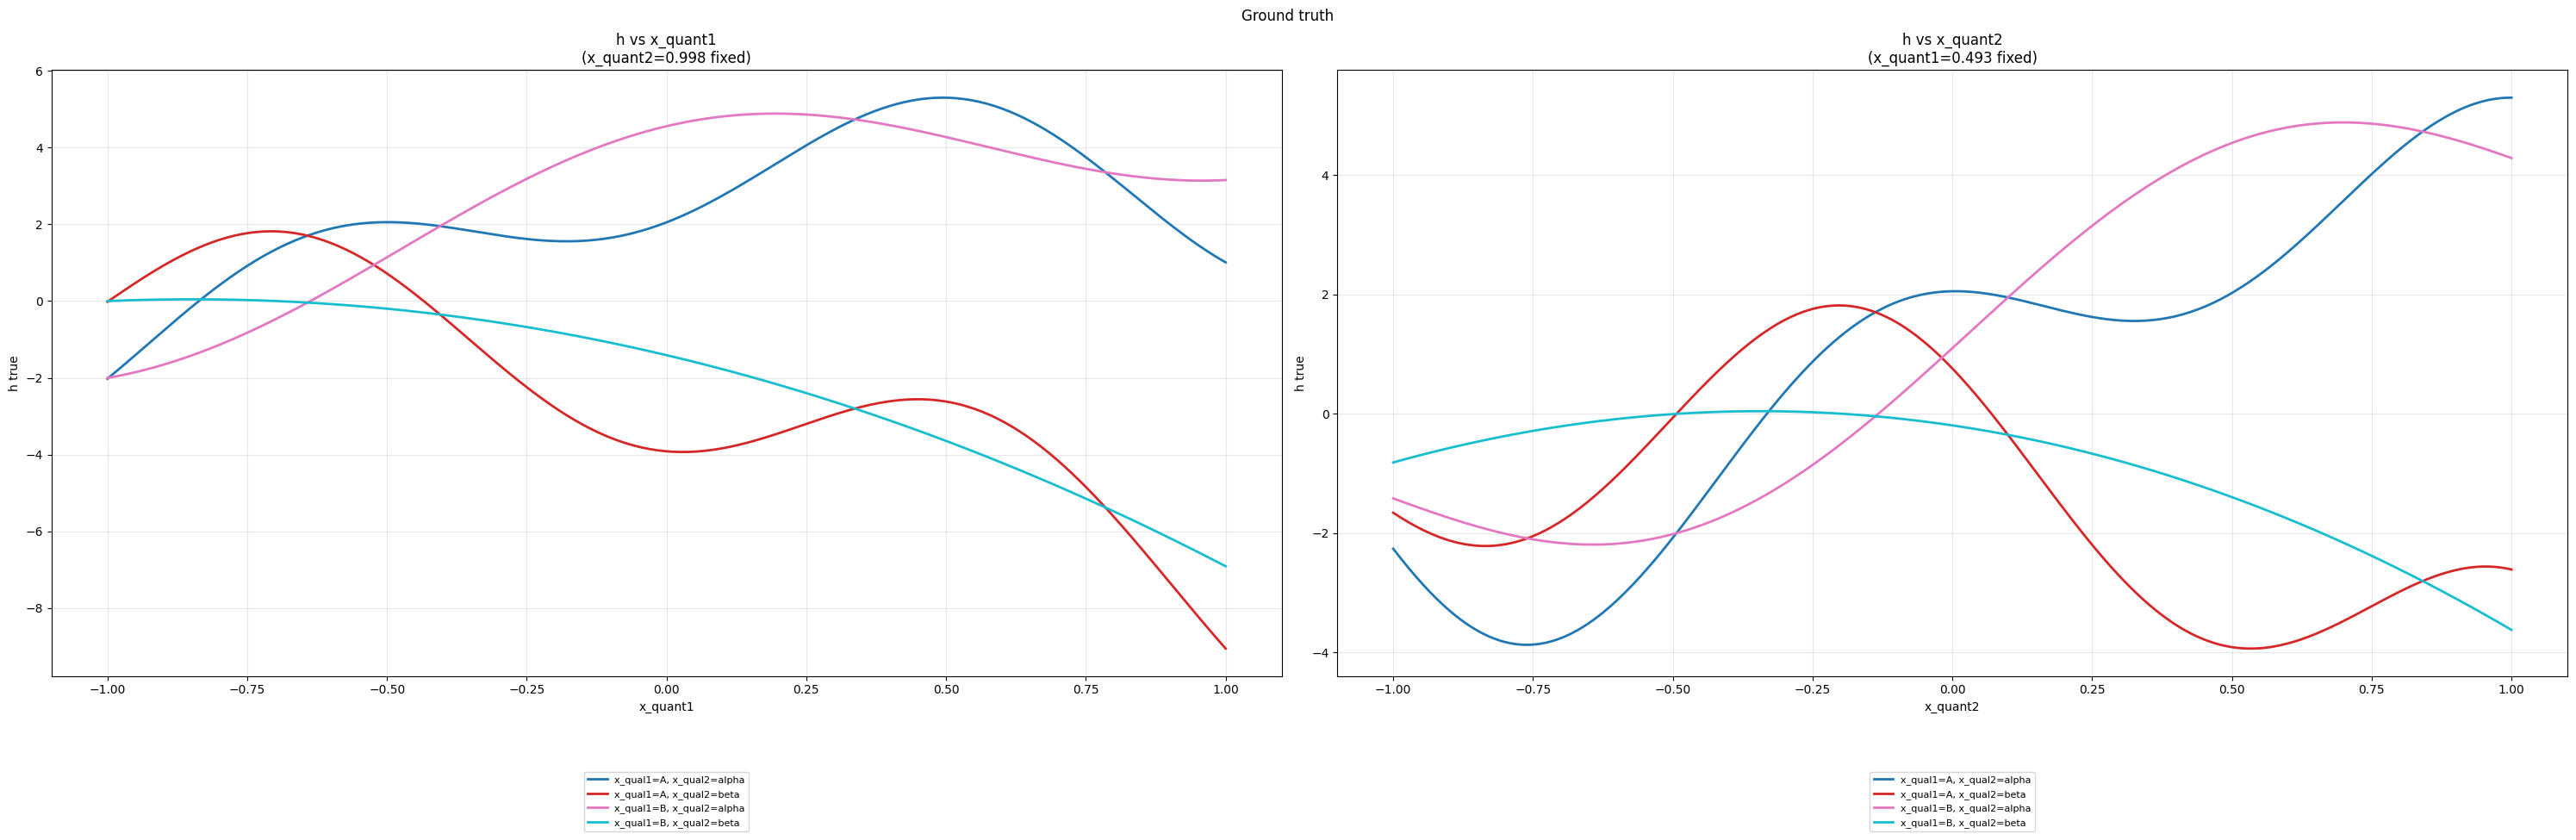

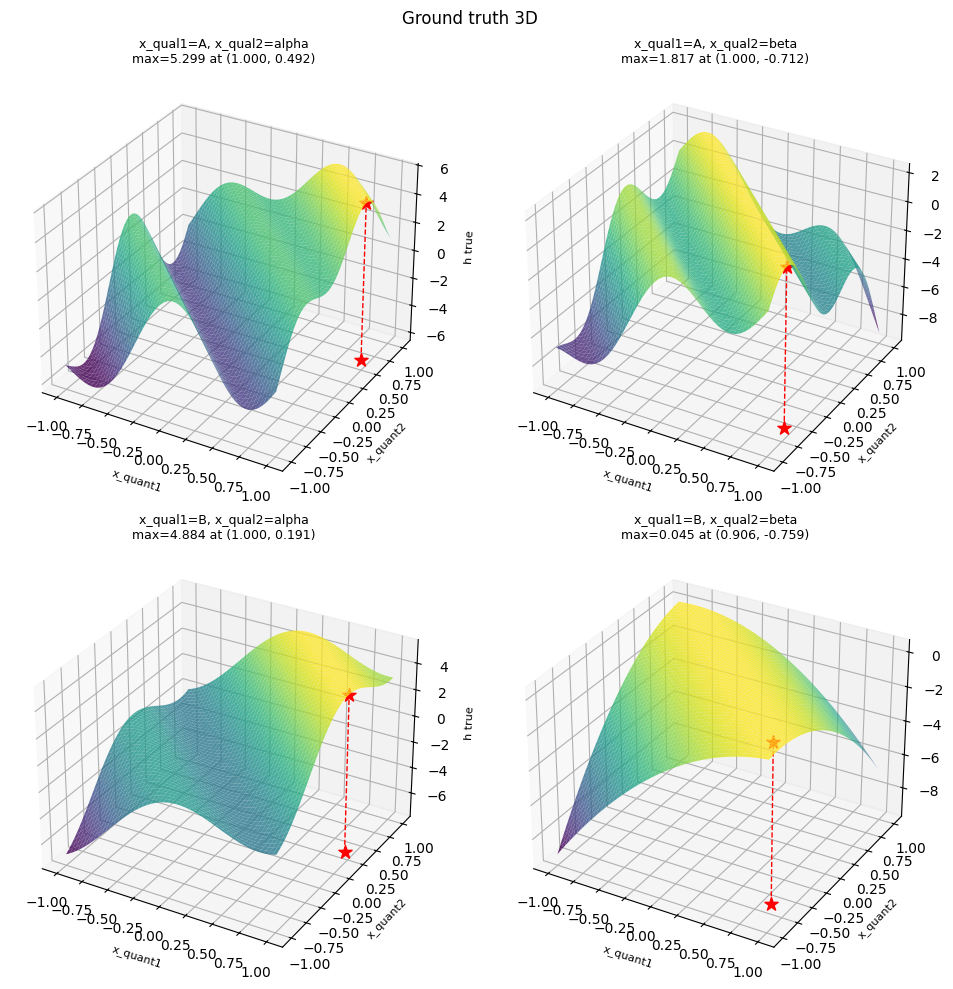

In [6]:
# True max
x_true_max, y_true_max, _, _ = XPRModA.calc_true_max(
    fn_gp_objective=fn_gp_objective, 
    vars_metadata=vars_metadata, 
    z=z, 
    n_grille=1000
)

XPRModA.print_opt_result(x=x_true_max, y=y_true_max, vars_metadata=vars_metadata)

# Plot true max 2d
plot_ground_truth(
    fn_gp_objective=fn_gp_objective,
    vars_metadata=vars_metadata,
    z=z,
    quant_fixed_vals=(
        (2, x_true_max[2]), 
        (3, x_true_max[3])
    ),
    n_points=300,
    figsize=(15,10)
)

# PLot true max 3d
plot_3d_ground_truth(
    fn_gp_objective=fn_gp_objective,
    vars_metadata=vars_metadata,
    z=z,
    quant_idx_1=2,
    quant_idx_2=3,
    n_points=300,
    n_cols=2,
    figsize=(5,5)
)


## **Benchmark.**

In [10]:
# Fixed hyperparams
fixed_hyperparams_dict = {
    "sampling_method": LHS,
    "sampling_criterion": "ese",
    "qei": "KBLB",
    "n_start": 20,
    }

# varying hyperparams
varying_hyperparams_dict = [
    ("n_init", [2, 6, 10, 14]),
    ("n_iter_bo", [30]),
    ("sigma_noise", [0.1, 1.0]),
    ("bo_criterion", ["EI", "LCB"]),
    ("kernel", [MixIntKernelType.GOWER])
]

seeds = list(range(0,15))

results = benchmark(
    fn_gp_objective=fn_gp_objective,
    vars_metadata=vars_metadata,
    z=z,
    x_true_max=x_true_max,
    y_true_max=y_true_max,
    seeds=seeds,
    fixed_hyperparams_dict=fixed_hyperparams_dict,
    varying_hyperparams_dict=varying_hyperparams_dict,
    save_path_results=os.path.join(os.getcwd(), "..", "..", "data", "xpr_moda_fn01_bo30", "results_seed_0_to_14_gower.json"),
    save_path_logs=os.path.join(os.getcwd(), "..", "..", "data", "logs.log"),
    max_n_points=30,
)


--- Experiments for hyperparameters ['n_init', 'n_iter_bo', 'sigma_noise', 'bo_criterion', 'kernel'] ---

   
(1/240) Running n_init=2, n_iter_bo=28, sigma_noise=0.1, bo_criterion=EI, kernel=MixIntKernelType.GOWER, seed=0...

      Results:
        x* = x_qual1 = A / x_qual2 = alpha / x_quant1 = 0.8153 / x_quant2 = 0.7235
        y* = 5.3481
        y_true_at_x_opt = 5.244

   
(2/240) Running n_init=2, n_iter_bo=28, sigma_noise=0.1, bo_criterion=EI, kernel=MixIntKernelType.GOWER, seed=1...

      Results:
        x* = x_qual1 = B / x_qual2 = alpha / x_quant1 = 0.8486 / x_quant2 = 0.3311
        y* = 4.9430
        y_true_at_x_opt = 4.883

   
(3/240) Running n_init=2, n_iter_bo=28, sigma_noise=0.1, bo_criterion=EI, kernel=MixIntKernelType.GOWER, seed=2...

      Results:
        x* = x_qual1 = B / x_qual2 = alpha / x_quant1 = 1.0000 / x_quant2 = 0.1758
        y* = 4.9663
        y_true_at_x_opt = 4.882

   
(4/240) Running n_init=2, n_iter_bo=28, sigma_noise=0.1, bo_criterion=EI, ke